# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

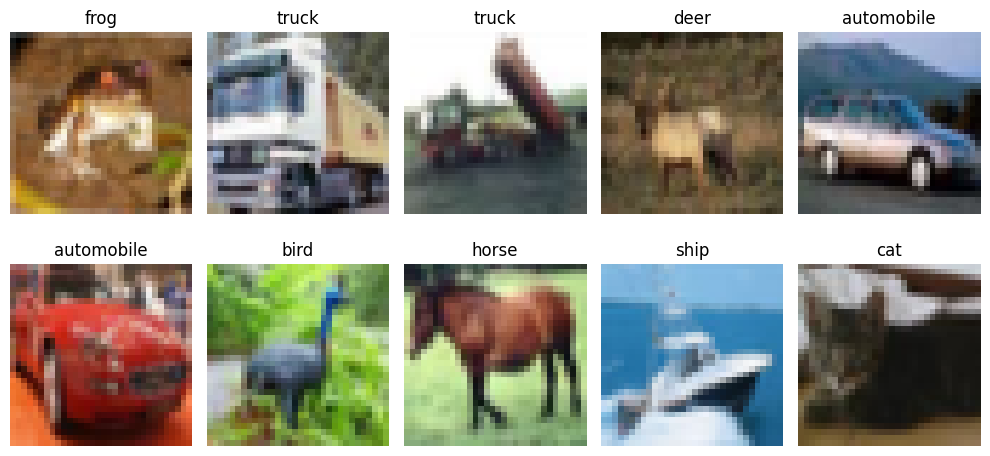

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [ ]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [ ]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2626 - loss: 2.0034 - val_accuracy: 0.3248 - val_loss: 1.8605
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3090 - loss: 1.8887 - val_accuracy: 0.3448 - val_loss: 1.8108
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3260 - loss: 1.8424 - val_accuracy: 0.3722 - val_loss: 1.7718
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3430 - loss: 1.7976 - val_accuracy: 0.3752 - val_loss: 1.7729
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3464 - loss: 1.7882 - val_accuracy: 0.3928 - val_loss: 1.7322
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3598 - loss: 1.7564 - val_accuracy: 0.3948 - val_loss: 1.7162
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3652 - loss: 1.7437 - val_accuracy: 0.4194 - val_loss: 1.6888
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.3704 - loss: 1.7273 - val_accuracy: 0.

In [ ]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4279 - loss: 1.6441
ANN Test Accuracy: 0.4278999865055084


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4717 - loss: 1.4794 - val_accuracy: 0.5476 - val_loss: 1.2424
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6167 - loss: 1.0984 - val_accuracy: 0.6048 - val_loss: 1.1579
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6758 - loss: 0.9309 - val_accuracy: 0.6568 - val_loss: 0.9649
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7176 - loss: 0.8149 - val_accuracy: 0.6926 - val_loss: 0.8724
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7481 - loss: 0.7223 - val_accuracy: 0.6604 - val_loss: 1.0266
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7756 - loss: 0.6393 - val_accuracy: 0.7360 - val_loss: 0.8207
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7988 - loss: 0.5690 - val_accuracy: 0.6656 - val_loss: 1.0445
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8156 - loss: 0.5207 - val_accuracy: 

In [ ]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6793 - loss: 1.0742
CNN Test Accuracy: 0.6793000102043152


## 📈 Compare Learning Curves

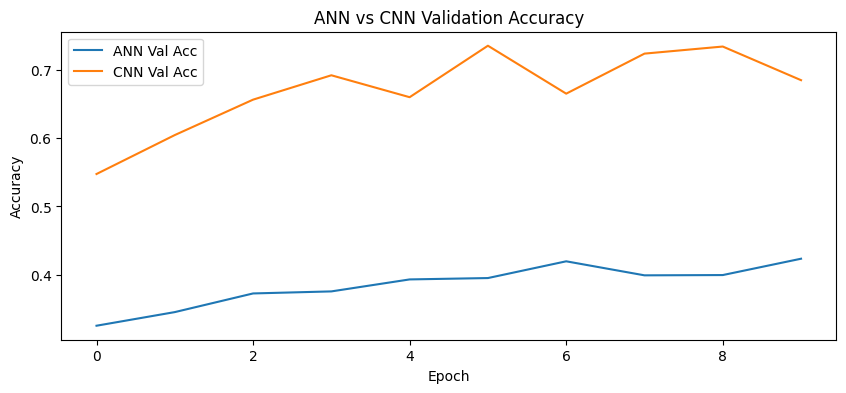

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [ ]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4279
1,CNN,0.6793


## Task 3: Increasing Training Epochs to 20

In this experiment, the CNN model is trained for 20 epochs instead of 10.

Objective:
- Observe whether longer training improves accuracy.
- Check if the model starts overfitting.
- Compare performance with the baseline CNN model.

In [ ]:
cnn20_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn20_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn20_history = cnn20_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64
)

cnn20_loss, cnn20_acc = cnn20_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN (20 Epochs) Accuracy:", cnn20_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.4782 - loss: 1.4647 - val_accuracy: 0.5300 - val_loss: 1.3404
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6154 - loss: 1.1101 - val_accuracy: 0.6308 - val_loss: 1.0516
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6714 - loss: 0.9413 - val_accuracy: 0.5862 - val_loss: 1.2222
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7110 - loss: 0.8302 - val_accuracy: 0.6668 - val_loss: 0.9451
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7456 - loss: 0.7288 - val_accuracy: 0.6688 - val_loss: 0.9981
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7708 - loss: 0.6505 - val_accuracy: 0.6998 - val_loss: 0.9228
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7924 - loss: 0.5914 - val_accuracy: 0.7204 - val_loss: 0.8502
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8125 - loss: 0.5286 - val_accuracy: 

## Task 4: Early Stopping

EarlyStopping is a regularization technique that stops training when the validation loss stops improving.

Benefits:
- Prevents overfitting.
- Saves training time.
- Restores the best-performing model weights.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_es_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_es_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_es_history = cnn_es_model.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

cnn_es_loss, cnn_es_acc = cnn_es_model.evaluate(
    x_test_norm,
    y_test
)

print("CNN + EarlyStopping Accuracy:", cnn_es_acc)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.4523 - loss: 1.5231 - val_accuracy: 0.5444 - val_loss: 1.2871
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6015 - loss: 1.1392 - val_accuracy: 0.4974 - val_loss: 1.4652
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6694 - loss: 0.9583 - val_accuracy: 0.5846 - val_loss: 1.1619
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7117 - loss: 0.8342 - val_accuracy: 0.5778 - val_loss: 1.2749
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7422 - loss: 0.7393 - val_accuracy: 0.7128 - val_loss: 0.8327
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7699 - loss: 0.6593 - val_accuracy: 0.6966 - val_loss: 0.9014
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7931 - loss: 0.5881 - val_accuracy: 0.7330 - val_loss: 0.8005
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8137 - loss: 0.5301 - val_accuracy: 

### Task 4: EarlyStopping

EarlyStopping was applied to prevent overfitting by monitoring validation accuracy.

Observation:
- Training stopped automatically when validation performance stopped improving.
- Final Test Accuracy: 71.26%
- Accuracy remained close to the original CNN model, indicating that the baseline CNN was already well-regularized.

## Task 5: Data Augmentation Training

Data augmentation generates modified versions of training images.

Techniques used:
- Random Horizontal Flip
- Random Rotation
- Random Zoom

Objective:
- Improve model generalization.
- Reduce overfitting.
- Increase robustness on unseen images.

In [ ]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

aug_loss, aug_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Accuracy:", aug_acc)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.3581 - loss: 1.7587 - val_accuracy: 0.4632 - val_loss: 1.4670
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.4594 - loss: 1.5046 - val_accuracy: 0.5182 - val_loss: 1.3166
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.4962 - loss: 1.4097 - val_accuracy: 0.5744 - val_loss: 1.2046
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5187 - loss: 1.3545 - val_accuracy: 0.5922 - val_loss: 1.1371
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5323 - loss: 1.3155 - val_accuracy: 0.5940 - val_loss: 1.1322
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.5466 - loss: 1.2804 - val_accuracy: 0.5988 - val_loss: 1.1382
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.5544 - loss: 1.2601 - val_accuracy: 0.6008 - val_loss: 1.1422
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5649 - loss: 1.2341 - val_accuracy: 

In [ ]:
comparison_extended = pd.DataFrame({
    "Model": [
        "ANN",
        "CNN",
        "CNN (20 Epochs)",
        "CNN + EarlyStopping",
        "CNN + Data Augmentation"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        cnn20_acc,
        cnn_es_acc,
        aug_acc
    ]
})

comparison_extended

,Model,Test Accuracy
0,ANN,0.4279
1,CNN,0.6793
2,CNN (20 Epochs),0.6911
3,CNN + EarlyStopping,0.7126
4,CNN + Data Augmentation,0.6424


# Observation

Training the CNN for 20 epochs slightly improved performance compared to the baseline CNN.

Test Accuracy: 69.11%

The model learned more patterns from the data, but the improvement became smaller after several epochs.

# Observation

EarlyStopping achieved the best performance among all experiments.

Test Accuracy: 71.26%

It stopped training when validation performance stopped improving and restored the best model weights.

# Observation

Data augmentation introduced more variation in training images using flipping, rotation, and zoom operations.

Test Accuracy: 64.24%

Although accuracy was lower in this experiment, augmentation generally helps improve model robustness and generalization when trained for longer durations.

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# Additional Experiments Completed

The following additional experiments were performed:

- CNN trained for 20 epochs
- CNN with EarlyStopping
- CNN with Data Augmentation

These experiments were conducted to study the impact of training duration, regularization, and data augmentation on model performance.

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**